In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('final.csv', index_col=0)

In [3]:
data['area_mean']

0      31.077
1      32.900
2      31.159
3      31.877
4      30.908
        ...  
194    30.404
195    30.952
196    28.653
197    29.266
198    34.898
Name: area_mean, Length: 199, dtype: float64

In [4]:
import numpy as np

In [5]:
data["class"] = np.where(data["melting_point"] >= 50, "stable", "non-stable")

In [6]:
data

,name,sequence,pI,NetCharge_pH7,Hydrophobizität,Dipol_Approx,Aromaticity,rmsd_mean,rmsd_std,gyrate-taf_mean,...,lj_contacts_protein_protein_mean,lj_contacts_protein_protein_std,lj_contacts_protein_water_mean,lj_contacts_protein_water_std,hbond_protein_protein_mean,hbond_protein_protein_std,hbond_protein_water_mean,hbond_protein_water_std,melting_point,class
0,H_Pin1_Y23L,KLPPGWEKRMSRSSGRVLYFNHITNASQWERPSG,10.932,3.850,-1.103,4.357,0.1176,0.217,0.032,0.970,...,556.0,0.0,640.867,23.348,18.283,2.061,96.576,4.860,45.3,non-stable
1,H_Pin1_Y24A,KLPPGWEKRMSRSSGRVYAFNHITNASQWERPSG,10.932,3.850,-1.162,4.357,0.1176,0.396,0.093,1.017,...,547.0,0.0,678.490,29.690,17.955,2.425,97.740,5.444,10.0,non-stable
2,H_Pin1_Y24F,KLPPGWEKRMSRSSGRVYFFNHITNASQWERPSG,10.932,3.850,-1.132,4.357,0.1471,0.194,0.029,0.976,...,557.0,0.0,643.920,22.461,17.673,2.009,97.396,4.993,51.4,stable
3,H_Pin1_Y24L,KLPPGWEKRMSRSSGRVYLFNHITNASQWERPSG,10.932,3.850,-1.103,4.357,0.1176,0.303,0.036,0.995,...,556.0,0.0,659.238,30.314,19.027,2.460,95.757,5.325,10.0,non-stable
4,H_Pin1_Y24W,KLPPGWEKRMSRSSGRVYWFNHITNASQWERPSG,10.932,3.850,-1.241,4.357,0.1471,0.179,0.023,0.979,...,561.0,0.0,638.761,23.294,18.063,2.318,96.976,5.134,52.9,stable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,cl_WW_LP1_6,PLPPGWEIRIDSGSGRIYFYNHNTKTTTWERPRL,9.713,2.049,-1.032,6.667,0.1471,0.171,0.021,0.966,...,568.0,0.0,630.686,21.991,20.085,2.246,94.121,4.811,85.0,stable
195,cl_WW_LP1_7,PLPPGWEIRIESGSGRIYFYNHNTKTTTWERPRL,9.713,2.051,-1.032,6.667,0.1471,0.192,0.022,0.980,...,571.0,0.0,643.238,26.053,20.411,2.329,94.981,4.876,79.5,stable
196,cl_WW_LP2_1,PLPPGWEIRIGSGSGSIYYYNSGSKTTTWERPRL,9.551,1.960,-0.794,6.000,0.1471,0.216,0.022,0.950,...,535.0,0.0,597.800,25.635,16.943,2.223,90.360,5.072,42.5,non-stable
197,cl_WW_LP2_7,PLPPGWEIRIGSGSGSIYYYNGSGKTTTWERPRL,9.551,1.960,-0.782,6.000,0.1471,0.165,0.021,0.953,...,531.0,0.0,608.690,22.117,16.745,2.139,90.509,4.653,0.0,non-stable


In [7]:
# Liste der fehlerhaften Peptide, z. B. aus Fehlerausgabe
missing_names = ["Du_tripzip4", "H_Pin1_Y23A", "manu_yap65_l30k"]


# Entferne Peptide, die keine Adjazenzdaten haben
df = data[~data["name"].isin(missing_names)].reset_index(drop=True)

In [8]:
df.to_csv("final.csv")

In [9]:
df['class'].value_counts()

class
stable        118
non-stable     81
Name: count, dtype: int64

In [10]:
df.keys()

Index(['name', 'sequence', 'pI', 'NetCharge_pH7', 'Hydrophobizität',
       'Dipol_Approx', 'Aromaticity', 'rmsd_mean', 'rmsd_std',
       'gyrate-taf_mean', 'gyrate-taf_std', 'energy_mean', 'energy_std',
       'area_mean', 'area_std', 'lj_contacts_protein_protein_mean',
       'lj_contacts_protein_protein_std', 'lj_contacts_protein_water_mean',
       'lj_contacts_protein_water_std', 'hbond_protein_protein_mean',
       'hbond_protein_protein_std', 'hbond_protein_water_mean',
       'hbond_protein_water_std', 'melting_point', 'class'],
      dtype='object')

In [11]:
adjacency = "/Users/moritzhuber/Documents/Forschi-Thomas/MODELL/data/adjacency/cl_WW_BS2_1_adjacency_matrix.npy"

In [12]:
import numpy as np

adj_matrix = np.load(adjacency)

In [13]:
adj_matrix

array([[0.        , 0.96606893, 0.87247517, ..., 0.46563562, 0.52089861,
        0.80934604],
       [0.96606893, 0.        , 0.98813412, ..., 0.99006733, 0.60589294,
        0.8039464 ],
       [0.87247517, 0.98813412, 0.        , ..., 0.96620225, 0.93287114,
        0.98046797],
       ...,
       [0.46563562, 0.99006733, 0.96620225, ..., 0.        , 0.98613426,
        0.83467769],
       [0.52089861, 0.60589294, 0.93287114, ..., 0.98613426, 0.        ,
        0.96760216],
       [0.80934604, 0.8039464 , 0.98046797, ..., 0.83467769, 0.96760216,
        0.        ]])

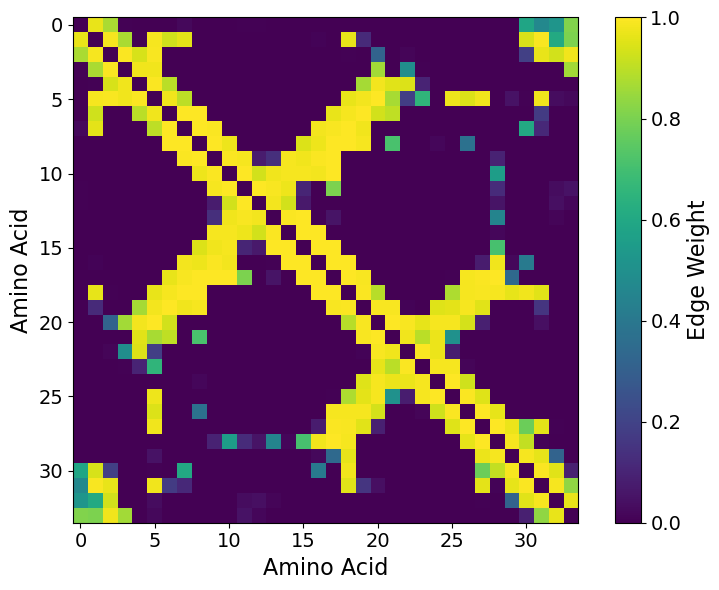

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(adj_matrix, cmap='viridis')

# Farbleiste hinzufügen und formatieren
cbar = plt.colorbar(label='Edge Weight')
cbar.ax.tick_params(labelsize=14)  # Zahlen auf der Farbleiste größer machen
cbar.set_label('Edge Weight', fontsize=16)  # Label größer

# Achsentitel (x und y)
plt.xlabel("Amino Acid", fontsize=16)
plt.ylabel("Amino Acid", fontsize=16)

# Achsenticks (x und y Zahlen)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("heatmap.png", dpi=800, bbox_inches='tight')
plt.show()

In [15]:
esm = "/Users/moritzhuber/Documents/Forschi-Thomas/MODELL/data/esm_embeddings/cl_WW_BS2_1.npy"

In [16]:
esm_data = np.load(esm)

In [17]:
esm_data.shape

(34, 1280)

In [18]:
esm_data

array([[ 0.00219505, -0.0720847 ,  0.03979307, ..., -0.00618961,
         0.19746344,  0.07464963],
       [ 0.22461301,  0.00849806, -0.01730062, ..., -0.13723268,
         0.24402373,  0.11248729],
       [ 0.08290187,  0.06543265,  0.02689319, ..., -0.12126584,
         0.3582289 ,  0.20526224],
       ...,
       [ 0.18650499, -0.17530714,  0.0190353 , ..., -0.2453762 ,
        -0.00479273,  0.14047858],
       [ 0.10880485,  0.00565146,  0.14409485, ..., -0.0941609 ,
         0.13486773,  0.11162056],
       [ 0.12710562, -0.02220863,  0.23016733, ..., -0.08398792,
         0.15164989,  0.05329068]], dtype=float32)

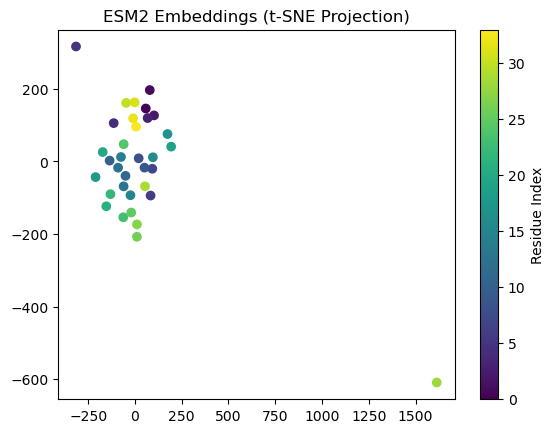

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X_2d = TSNE(n_components=2, perplexity=5).fit_transform(esm_data)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=range(esm_data.shape[0]), cmap='viridis')
plt.title("ESM2 Embeddings (t-SNE Projection)")
plt.colorbar(label='Residue Index')

In [20]:
data_f = pd.read_csv('final.csv')

In [21]:
data_f.keys()

Index(['Unnamed: 0', 'name', 'sequence', 'pI', 'NetCharge_pH7',
       'Hydrophobizität', 'Dipol_Approx', 'Aromaticity', 'rmsd_mean',
       'rmsd_std', 'gyrate-taf_mean', 'gyrate-taf_std', 'energy_mean',
       'energy_std', 'area_mean', 'area_std',
       'lj_contacts_protein_protein_mean', 'lj_contacts_protein_protein_std',
       'lj_contacts_protein_water_mean', 'lj_contacts_protein_water_std',
       'hbond_protein_protein_mean', 'hbond_protein_protein_std',
       'hbond_protein_water_mean', 'hbond_protein_water_std', 'melting_point',
       'class'],
      dtype='object')

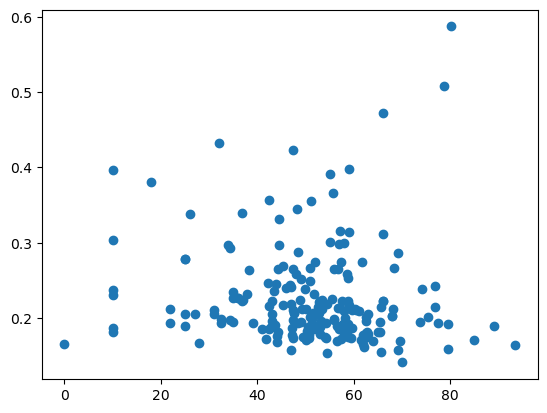

In [22]:
#plt.scatter(data_f['melting_point'], data_f['hbond_protein_protein_mean'])
plt.scatter(data_f['melting_point'], data_f['rmsd_mean'])

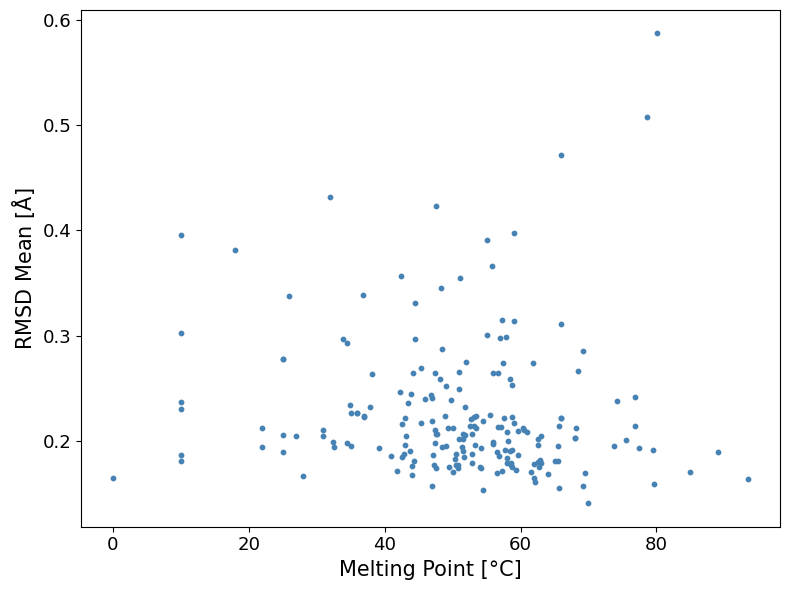

In [24]:

plt.figure(figsize=(8, 6))  # Größere Figur für bessere Lesbarkeit

# Streudiagramm mit Farbe, Transparenz und größerem Marker
plt.scatter(
    data_f['melting_point'],
    data_f['rmsd_mean'],
    c='steelblue',
    s=10
)

# Achsentitel mit Einheiten und schöner Formatierung
plt.xlabel("Melting Point [°C]", fontsize=15)
plt.ylabel(r"RMSD Mean [$\mathrm{\AA}$]", fontsize=15)


# Rasterlinien hinzufügen
#plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Achsen-Ticks vergrößern
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Optional: Layout anpassen, damit alles gut passt
plt.tight_layout()

plt.savefig("/Users/moritzhuber/Documents/Forschi-Thomas/Bericht/img/rmsd_mean.png", dpi=700)

# Plot anzeigen
plt.show()


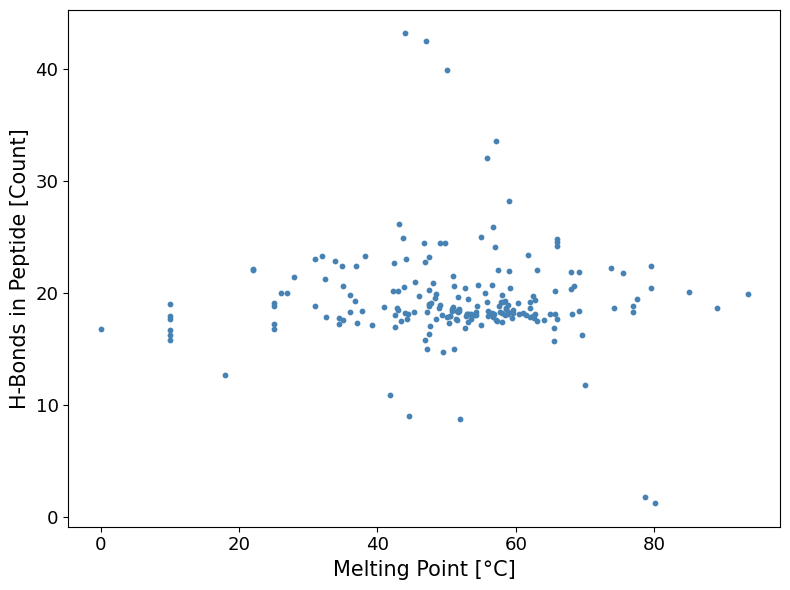

In [25]:

plt.figure(figsize=(8, 6))  # Größere Figur für bessere Lesbarkeit

# Streudiagramm mit Farbe, Transparenz und größerem Marker
plt.scatter(
    data_f['melting_point'],
    data_f['hbond_protein_protein_mean'],
    c='steelblue',
    s=10
)

# Achsentitel mit Einheiten und schöner Formatierung
plt.xlabel("Melting Point [°C]", fontsize=15)
plt.ylabel(r"H-Bonds in Peptide [Count]", fontsize=15)


# Rasterlinien hinzufügen
#plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Achsen-Ticks vergrößern
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Optional: Layout anpassen, damit alles gut passt
plt.tight_layout()
plt.savefig("/Users/moritzhuber/Documents/Forschi-Thomas/Bericht/img/h_bonds_pp.png", dpi=700)

# Plot anzeigen
plt.show()


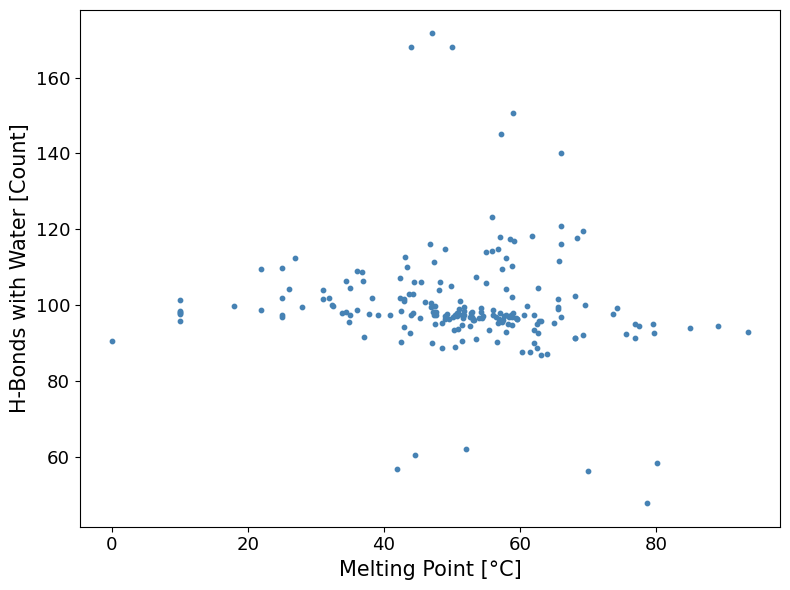

In [26]:

plt.figure(figsize=(8, 6))  # Größere Figur für bessere Lesbarkeit

# Streudiagramm mit Farbe, Transparenz und größerem Marker
plt.scatter(
    data_f['melting_point'],
    data_f['hbond_protein_water_mean'],
    c='steelblue',
    s=10
)

# Achsentitel mit Einheiten und schöner Formatierung
plt.xlabel("Melting Point [°C]", fontsize=15)
plt.ylabel(r"H-Bonds with Water [Count]", fontsize=15)


# Rasterlinien hinzufügen
#plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Achsen-Ticks vergrößern
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Optional: Layout anpassen, damit alles gut passt
plt.tight_layout()
plt.savefig("/Users/moritzhuber/Documents/Forschi-Thomas/Bericht/img/h_bonds_pw.png", dpi=700)

# Plot anzeigen
plt.show()


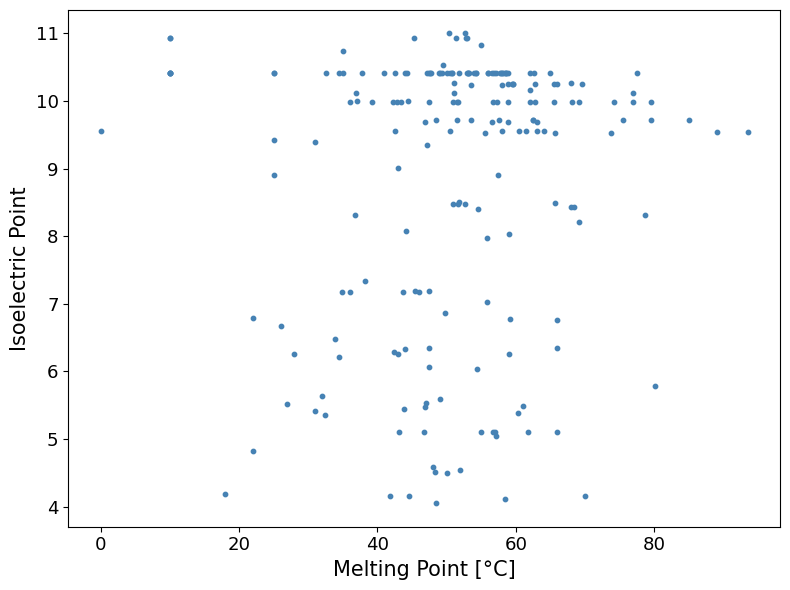

In [27]:

plt.figure(figsize=(8, 6))  # Größere Figur für bessere Lesbarkeit

# Streudiagramm mit Farbe, Transparenz und größerem Marker
plt.scatter(
    data_f['melting_point'],
    data_f['pI'],
    c='steelblue',
    s=10
)

# Achsentitel mit Einheiten und schöner Formatierung
plt.xlabel("Melting Point [°C]", fontsize=15)
plt.ylabel(r"Isoelectric Point", fontsize=15)


# Rasterlinien hinzufügen
#plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Achsen-Ticks vergrößern
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Optional: Layout anpassen, damit alles gut passt
plt.tight_layout()
plt.savefig("/Users/moritzhuber/Documents/Forschi-Thomas/Bericht/img/pI_mean.png", dpi=700)

# Plot anzeigen
plt.show()


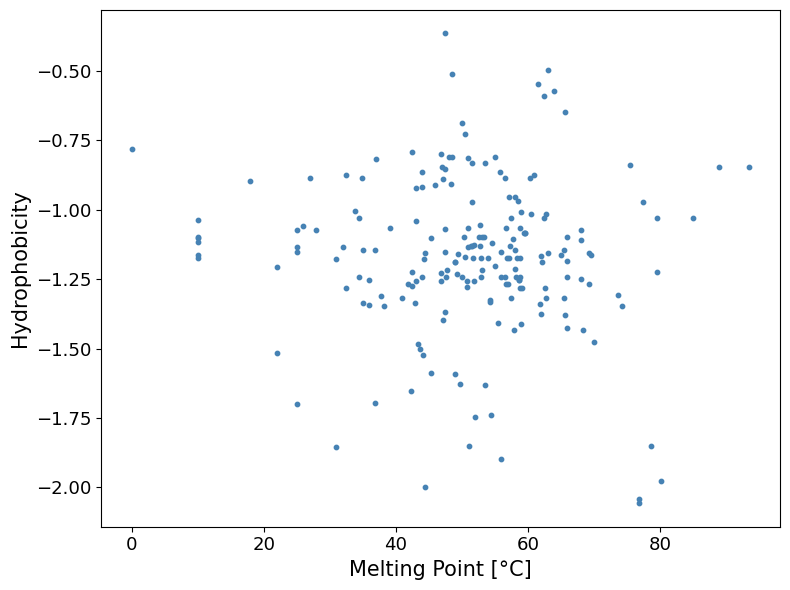

In [28]:

plt.figure(figsize=(8, 6))  # Größere Figur für bessere Lesbarkeit

# Streudiagramm mit Farbe, Transparenz und größerem Marker
plt.scatter(
    data_f['melting_point'],
    data_f['Hydrophobizität'],
    c='steelblue',
    s=10
)

# Achsentitel mit Einheiten und schöner Formatierung
plt.xlabel("Melting Point [°C]", fontsize=15)
plt.ylabel(r"Hydrophobicity", fontsize=15)


# Rasterlinien hinzufügen
#plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Achsen-Ticks vergrößern
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Optional: Layout anpassen, damit alles gut passt
plt.tight_layout()
plt.savefig("/Users/moritzhuber/Documents/Forschi-Thomas/Bericht/img/hydrophitität_mean.png", dpi=700)

# Plot anzeigen
plt.show()


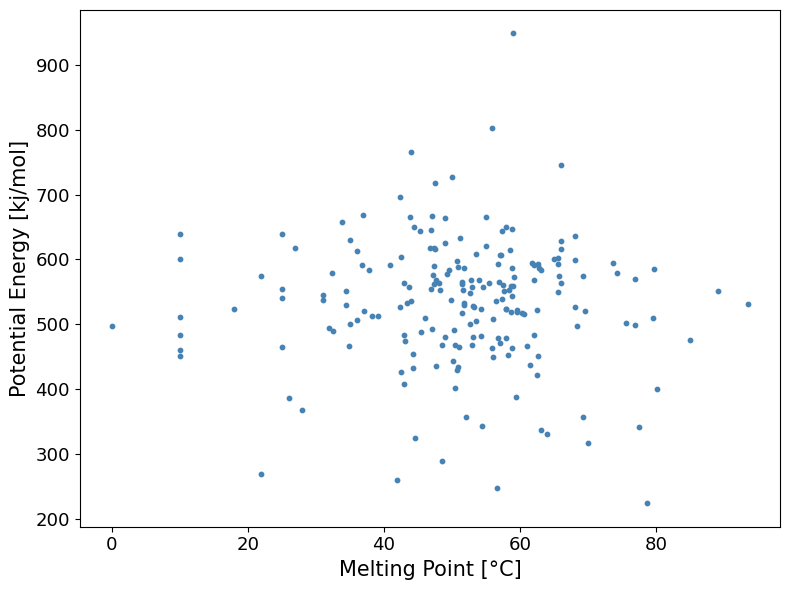

In [29]:

plt.figure(figsize=(8, 6))  # Größere Figur für bessere Lesbarkeit

# Streudiagramm mit Farbe, Transparenz und größerem Marker
plt.scatter(
    data_f['melting_point'],
    data_f['energy_mean'],
    c='steelblue',
    s=10
)

# Achsentitel mit Einheiten und schöner Formatierung
plt.xlabel("Melting Point [°C]", fontsize=15)
plt.ylabel(r"Potential Energy [kj/mol]", fontsize=15)


# Rasterlinien hinzufügen
#plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Achsen-Ticks vergrößern
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Optional: Layout anpassen, damit alles gut passt
plt.tight_layout()
plt.savefig("/Users/moritzhuber/Documents/Forschi-Thomas/Bericht/img/energy_mean.png", dpi=700)

# Plot anzeigen
plt.show()
